<a href="https://colab.research.google.com/github/TegarAdh/Machine-Learning/blob/main/Introduction%20to%20CNN/Garbage_Classification_CNN--ResNet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Machine Learning - Image Classification Using Transfer Learning**
---

Dataset : [Garbage Image Dataset](https://www.kaggle.com/datasets/farzadnekouei/trash-type-image-dataset)

Auth    : [Tegar Adhi Nugraha Christ During](https://github.com/TegarAdh)


## ***Download Dataset***

In [ ]:
!kaggle datasets download -d farzadnekouei/trash-type-image-dataset
!unzip -q trash-type-image-dataset.zip -d dataset


Dataset URL: https://www.kaggle.com/datasets/farzadnekouei/trash-type-image-dataset
License(s): unknown
100% 40.9M/40.9M [00:03<00:00, 13.7MB/s]



## **Import Library**

In [ ]:
import os
import shutil
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import *
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input


## **Konfigurasi Hyperparameter**

In [ ]:
# KONFIGURASI UTAMA — definisikan di sini

IMG_SIZE    = 224      # ukuran input ResNet50
BATCH_SIZE  = 32
EPOCHS_INIT = 20       # fase 1: feature extraction
EPOCHS_FT   = 15       # fase 2: fine-tuning
RANDOM_SEED = 42

tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


## **Load Dataset**

In [ ]:
DATASET_DIR = '/content/dataset/TrashType_Image_Dataset'

classes = sorted(os.listdir(DATASET_DIR))
print('Classes:', classes)


Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [ ]:
class_counts = []

for cls in classes:
    path = os.path.join(DATASET_DIR, cls)
    class_counts.append(len(os.listdir(path)))

df = pd.DataFrame({'Class': classes, 'Count': class_counts})
df


,Class,Count
0,cardboard,403
1,glass,501
2,metal,410
3,paper,594
4,plastic,482
5,trash,137


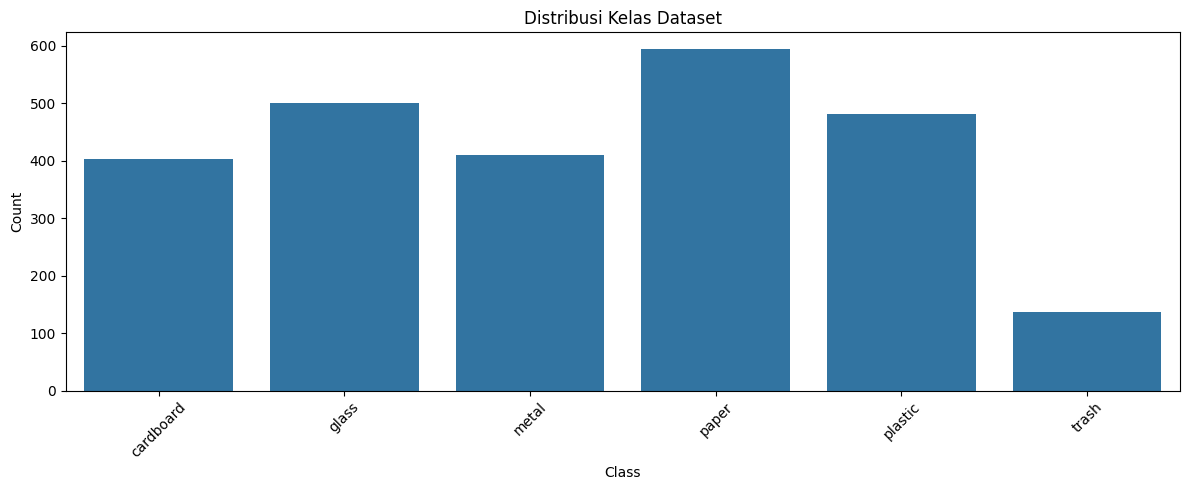

In [ ]:
plt.figure(figsize=(12, 5))
sns.barplot(data=df, x='Class', y='Count')
plt.xticks(rotation=45)
plt.title('Distribusi Kelas Dataset')
plt.tight_layout()
plt.show()


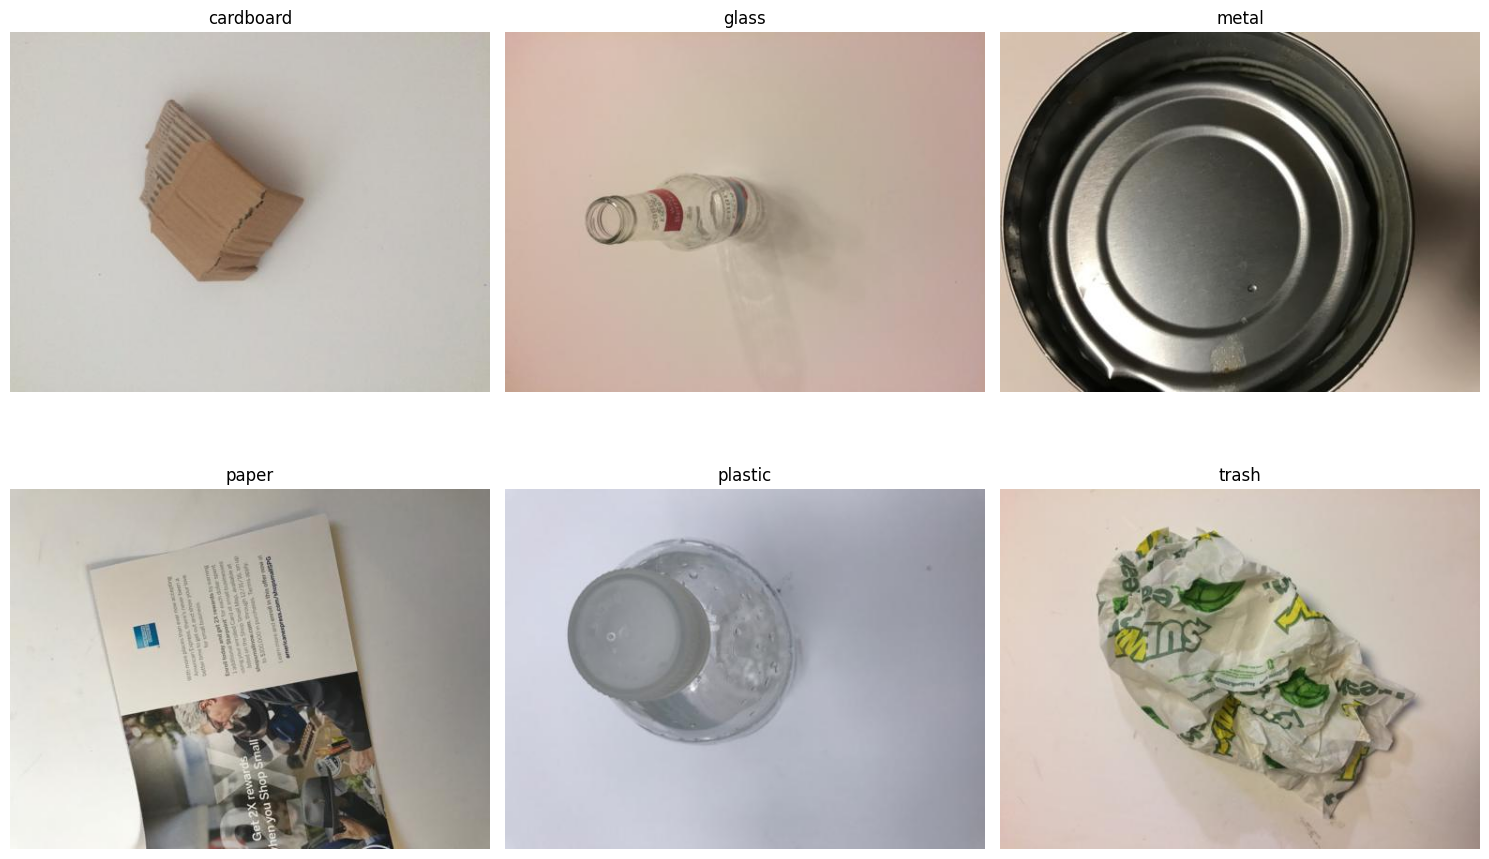

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, cls in enumerate(classes):
    folder = os.path.join(DATASET_DIR, cls)
    img_name = random.choice(os.listdir(folder))
    img = Image.open(os.path.join(folder, img_name))
    axes[idx].imshow(img)
    axes[idx].set_title(cls)
    axes[idx].axis('off')

plt.tight_layout()
plt.show()


## **Split Dataset**

In [ ]:
SOURCE_DIR = '/content/dataset/TrashType_Image_Dataset'
OUTPUT_DIR = '/content/trash_split'

TRAIN_DIR = os.path.join(OUTPUT_DIR, 'train')
VAL_DIR   = os.path.join(OUTPUT_DIR, 'val')
TEST_DIR  = os.path.join(OUTPUT_DIR, 'test')

os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Classes:', classes)


Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [ ]:
for cls in classes:
    files = os.listdir(os.path.join(SOURCE_DIR, cls))

    train_files, temp_files = train_test_split(
        files, test_size=0.3, random_state=RANDOM_SEED
    )

    val_files, test_files = train_test_split(
        temp_files, test_size=0.5, random_state=RANDOM_SEED
    )

    for split_name, split_files in zip(
        ['train', 'val', 'test'],
        [train_files, val_files, test_files]
    ):
        split_dir = os.path.join(OUTPUT_DIR, split_name, cls)
        os.makedirs(split_dir, exist_ok=True)
        for file in split_files:
            shutil.copy(
                os.path.join(SOURCE_DIR, cls, file),
                os.path.join(split_dir, file)
            )

print('Dataset split selesai!')


Dataset split selesai!


## **Data Processing**


In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [ ]:
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print('Class indices (generator):', train_generator.class_indices)


Found 1766 images belonging to 6 classes.
Found 378 images belonging to 6 classes.
Found 383 images belonging to 6 classes.
Class indices (generator): {'cardboard': 0, 'glass': 1, 'metal': 2, 'paper': 3, 'plastic': 4, 'trash': 5}


In [ ]:
train_labels = train_generator.classes

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weight_dict = dict(enumerate(weights))
print('Class weight dict:', class_weight_dict)


Class weight dict: {0: np.float64(1.0437352245862883), 1: np.float64(0.840952380952381), 2: np.float64(1.0255516840882695), 3: np.float64(0.7092369477911646), 4: np.float64(0.8733926805143423), 5: np.float64(3.0982456140350876)}


## **ResNet50 Transfer Learning**

In [ ]:
base_model = ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

for layer in base_model.layers:
    layer.trainable = False

print(f'Base model layers: {len(base_model.layers)}')
print(f'Trainable layers (fase 1): {sum(1 for l in base_model.layers if l.trainable)}')


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Base model layers: 175
Trainable layers (fase 1): 0


In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(len(classes), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,777,862 (94.52 MB)

 Trainable params: 1,186,054 (4.52 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=1,
        verbose=1
    ),
    ModelCheckpoint(
        'best_resnet50.keras',
        save_best_only=True,
        verbose=1
    )
]


## **Training — Fase 1: Feature Extraction**

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_INIT,
    callbacks=callbacks,
    class_weight=class_weight_dict
)


Epoch 1/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 521ms/step - accuracy: 0.2860 - loss: 2.1070
Epoch 1: val_loss improved from None to 0.93196, saving model to best_resnet50.keras

Epoch 1: finished saving model to best_resnet50.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 57s 741ms/step - accuracy: 0.3692 - loss: 1.8458 - val_accuracy: 0.6984 - val_loss: 0.9320 - learning_rate: 1.0000e-04
Epoch 2/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.5759 - loss: 1.1710
Epoch 2: val_loss improved from 0.93196 to 0.67741, saving model to best_resnet50.keras

Epoch 2: finished saving model to best_resnet50.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 26s 466ms/step - accuracy: 0.5968 - loss: 1.1200 - val_accuracy: 0.7963 - val_loss: 0.6774 - learning_rate: 1.0000e-04
Epoch 3/20
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.6565 - loss: 0.9174
Epoch 3: val_loss improved from 0.67741 to 0.56828, saving model to best_resnet50.keras

Epoch 3: finished saving model to best_resnet50.keras
56/56 ━━━━━━━━━━━━━━━━━━

## **Training — Fase 2: Fine-Tuning**

In [ ]:
for layer in base_model.layers[-30:]:
    layer.trainable = True

print(f'Trainable layers (fase 2): {sum(1 for l in base_model.layers if l.trainable)} dari {len(base_model.layers)} layer base_model')

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


Trainable layers (fase 2): 30 dari 175 layer base_model


In [ ]:
fine_history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_FT,
    callbacks=callbacks,
    class_weight=class_weight_dict
)


Epoch 1/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 548ms/step - accuracy: 0.8145 - loss: 0.4919
Epoch 1: val_loss improved from 0.38308 to 0.38267, saving model to best_resnet50.keras

Epoch 1: finished saving model to best_resnet50.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 61s 723ms/step - accuracy: 0.8114 - loss: 0.5032 - val_accuracy: 0.8915 - val_loss: 0.3827 - learning_rate: 1.0000e-05
Epoch 2/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.8407 - loss: 0.4878
Epoch 2: val_loss improved from 0.38267 to 0.38131, saving model to best_resnet50.keras

Epoch 2: finished saving model to best_resnet50.keras
56/56 ━━━━━━━━━━━━━━━━━━━━ 27s 475ms/step - accuracy: 0.8347 - loss: 0.4684 - val_accuracy: 0.8995 - val_loss: 0.3813 - learning_rate: 1.0000e-05
Epoch 3/15
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.8217 - loss: 0.4775
Epoch 3: val_loss improved from 0.38131 to 0.37693, saving model to best_resnet50.keras

Epoch 3: finished saving model to best_resnet50.keras
56/56 ━━━━━━━━━━━━━━━

## **Plot Training History**

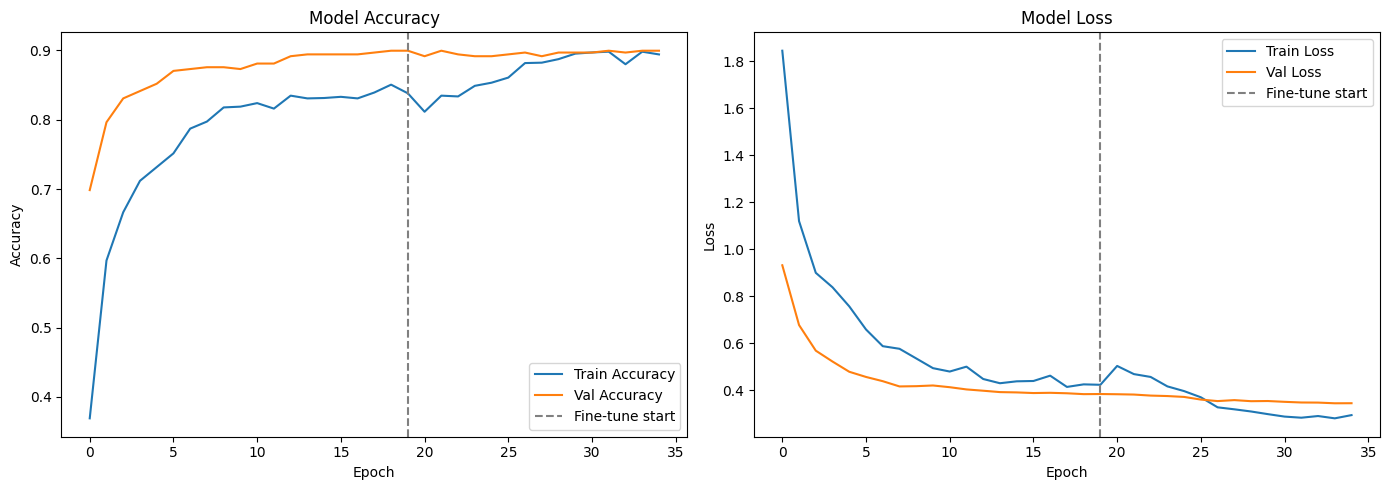

In [ ]:
def combine_history(h1, h2):
    combined = {}
    for key in h1.history:
        combined[key] = h1.history[key] + h2.history[key]
    return combined

all_history = combine_history(history, fine_history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(all_history['accuracy'], label='Train Accuracy')
axes[0].plot(all_history['val_accuracy'], label='Val Accuracy')
axes[0].axvline(x=len(history.history['accuracy'])-1,
               color='gray', linestyle='--', label='Fine-tune start')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Loss
axes[1].plot(all_history['loss'], label='Train Loss')
axes[1].plot(all_history['val_loss'], label='Val Loss')
axes[1].axvline(x=len(history.history['loss'])-1,
               color='gray', linestyle='--', label='Fine-tune start')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()


## **Analisis Overfitting**

In [ ]:
train_acc_final  = all_history['accuracy'][-1]
val_acc_final    = all_history['val_accuracy'][-1]
train_loss_final = all_history['loss'][-1]
val_loss_final   = all_history['val_loss'][-1]

acc_gap  = train_acc_final - val_acc_final
loss_gap = val_loss_final - train_loss_final

print('=== Kondisi akhir training ===')
print(f'Train Accuracy : {train_acc_final:.4f}')
print(f'Val Accuracy   : {val_acc_final:.4f}')
print(f'Gap Accuracy   : {acc_gap:.4f}  ({acc_gap*100:.2f}%)')
print()
print(f'Train Loss     : {train_loss_final:.4f}')
print(f'Val Loss       : {val_loss_final:.4f}')
print(f'Gap Loss       : {loss_gap:.4f}')
print()

ACC_GAP_THRESHOLD = 0.10

is_overfitting = acc_gap > ACC_GAP_THRESHOLD

if is_overfitting:
    print(f'>> TERINDIKASI OVERFITTING (gap akurasi {acc_gap*100:.2f}% > {ACC_GAP_THRESHOLD*100:.0f}%)')
else:
    print(f'>> TIDAK terindikasi overfitting yang signifikan (gap akurasi hanya {acc_gap*100:.2f}%)')
    print('   Kurva train dan validation bergerak berdekatan sepanjang training,')
    print('   artinya model men-generalisasi dengan baik ke data yang belum pernah dilihat.')


=== Kondisi akhir training ===
Train Accuracy : 0.8941
Val Accuracy   : 0.8995
Gap Accuracy   : -0.0054  (-0.54%)

Train Loss     : 0.2937
Val Loss       : 0.3444
Gap Loss       : 0.0507

>> TIDAK terindikasi overfitting yang signifikan (gap akurasi hanya -0.54%)
   Kurva train dan validation bergerak berdekatan sepanjang training,
   artinya model men-generalisasi dengan baik ke data yang belum pernah dilihat.


## **Evaluation**

In [ ]:
test_generator.reset()

pred_probs  = model.predict(test_generator, verbose=1)
pred_labels = np.argmax(pred_probs, axis=1)
true_labels = test_generator.classes

idx_to_class = {v: k for k, v in test_generator.class_indices.items()}
class_names  = [idx_to_class[i] for i in sorted(idx_to_class)]

print('Jumlah sampel test :', len(true_labels))
print('Jumlah prediksi    :', len(pred_labels))


12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 682ms/step
Jumlah sampel test : 383
Jumlah prediksi    : 383


In [ ]:
print(classification_report(
    true_labels,
    pred_labels,
    target_names=class_names
))


              precision    recall  f1-score   support

   cardboard       0.96      0.84      0.89        61
       glass       0.95      0.83      0.89        76
       metal       0.79      0.95      0.86        62
       paper       0.87      0.92      0.90        90
     plastic       0.88      0.82      0.85        73
       trash       0.65      0.81      0.72        21

    accuracy                           0.87       383
   macro avg       0.85      0.86      0.85       383
weighted avg       0.88      0.87      0.87       383



In [ ]:
acc       = accuracy_score(true_labels, pred_labels)
precision = precision_score(true_labels, pred_labels, average='weighted')
recall    = recall_score(true_labels, pred_labels, average='weighted')
f1        = f1_score(true_labels, pred_labels, average='weighted')

print(f'Accuracy  : {acc:.4f}')
print(f'Precision : {precision:.4f}')
print(f'Recall    : {recall:.4f}')
print(f'F1-Score  : {f1:.4f}')


Accuracy  : 0.8695
Precision : 0.8793
Recall    : 0.8695
F1-Score  : 0.8707


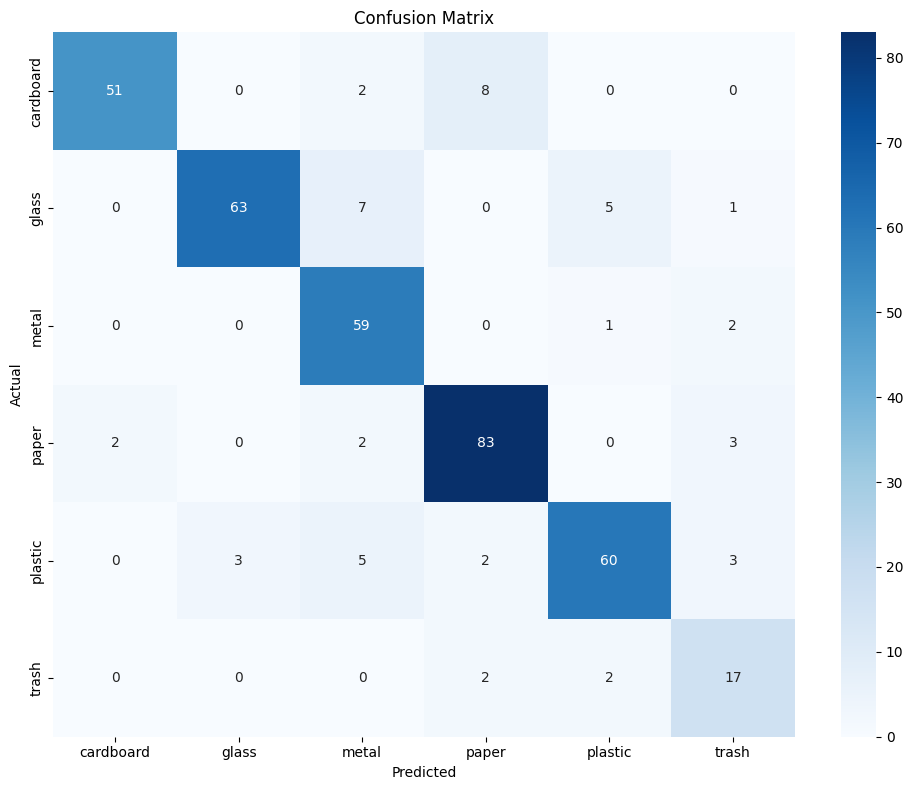

In [ ]:
cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()


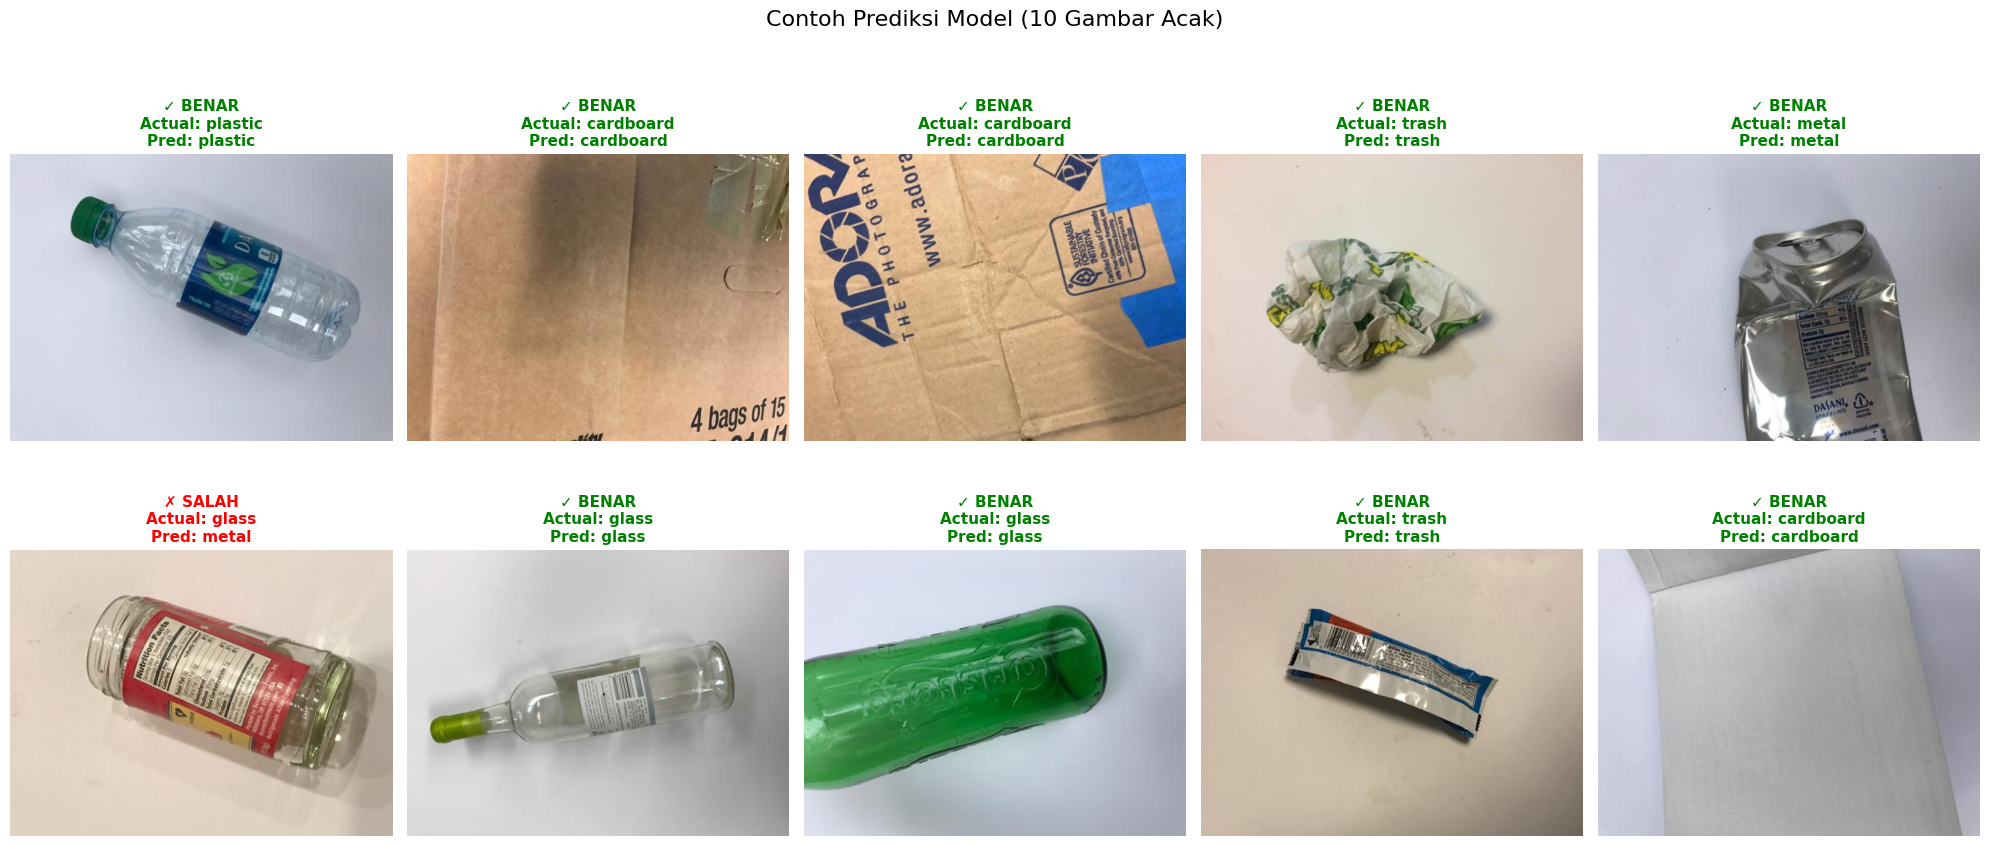

In [ ]:
test_filepaths = test_generator.filepaths

random.seed(RANDOM_SEED)
sample_indices = random.sample(range(len(test_filepaths)), 10)

fig, axes = plt.subplots(2, 5, figsize=(20, 9))
axes = axes.flatten()

for i, idx in enumerate(sample_indices):
    img_path = test_filepaths[idx]
    img = Image.open(img_path)

    true_label = class_names[true_labels[idx]]
    pred_label = class_names[pred_labels[idx]]
    is_correct = true_label == pred_label

    axes[i].imshow(img)
    axes[i].axis('off')

    color = 'green' if is_correct else 'red'
    status = '✓ BENAR' if is_correct else '✗ SALAH'

    axes[i].set_title(
        f"{status}\nActual: {true_label}\nPred: {pred_label}",
        color=color,
        fontsize=11,
        fontweight='bold'
    )

plt.suptitle('Contoh Prediksi Model (10 Gambar Acak)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
from IPython.display import display, Javascript, Image as IPImage
from google.colab.output import eval_js
from base64 import b64decode

def take_photo(filename='foto_kamera.jpg', quality=0.9):
    js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const capture = document.createElement('button');
      capture.textContent = 'Ambil Foto';
      div.appendChild(capture);

      const video = document.createElement('video');
      video.style.display = 'block';
      const stream = await navigator.mediaDevices.getUserMedia({video: true});

      document.body.appendChild(div);
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      await new Promise((resolve) => capture.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);
      stream.getVideoTracks()[0].stop();
      div.remove();
      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

<IPython.core.display.Javascript object>

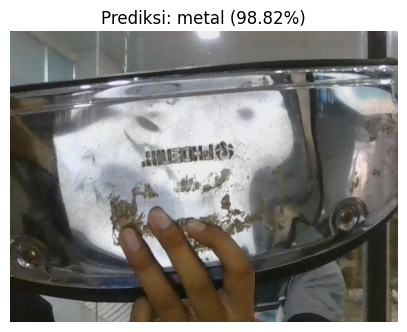

=== Hasil Prediksi ===
metal       : 98.82%
paper       :  0.75%
plastic     :  0.33%
glass       :  0.06%
cardboard   :  0.04%
trash       :  0.01%
--- Pengambilan foto ke-2/4 ---


<IPython.core.display.Javascript object>

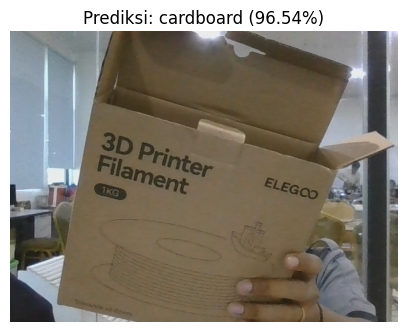

=== Hasil Prediksi ===
cardboard   : 96.54%
paper       :  2.76%
plastic     :  0.59%
trash       :  0.07%
glass       :  0.02%
metal       :  0.02%
--- Pengambilan foto ke-3/4 ---


<IPython.core.display.Javascript object>

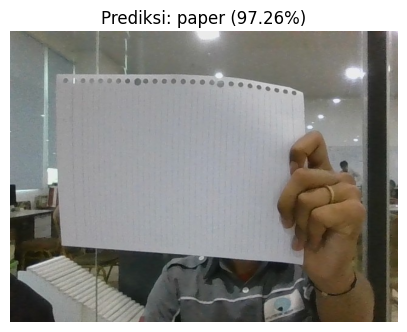

=== Hasil Prediksi ===
paper       : 97.26%
cardboard   :  1.40%
plastic     :  0.61%
trash       :  0.37%
metal       :  0.28%
glass       :  0.08%
--- Pengambilan foto ke-4/4 ---


<IPython.core.display.Javascript object>

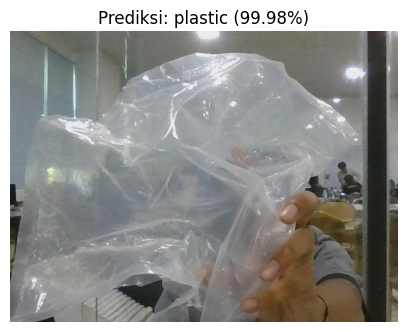

=== Hasil Prediksi ===
plastic     : 99.98%
glass       :  0.01%
paper       :  0.00%
metal       :  0.00%
trash       :  0.00%
cardboard   :  0.00%


,foto_ke,prediksi,confidence
0,2,cardboard,0.965394
1,3,paper,0.972555
2,4,plastic,0.999835


In [ ]:
def predict_from_camera(model, class_names, img_size=IMG_SIZE):
    filename = take_photo()

    img = Image.open(filename).convert('RGB')
    img_resized = img.resize((img_size, img_size))

    img_array = np.array(img_resized).astype('float32')
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)

    pred_probs = model.predict(img_array, verbose=0)[0]
    pred_idx   = np.argmax(pred_probs)
    pred_class = class_names[pred_idx]
    confidence = pred_probs[pred_idx]

    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f'Prediksi: {pred_class} ({confidence*100:.2f}%)')
    plt.show()

    print('=== Hasil Prediksi ===')
    for cls, prob in sorted(zip(class_names, pred_probs), key=lambda x: -x[1]):
        print(f'{cls:12s}: {prob*100:5.2f}%')

    return pred_class, confidence
pred_class, confidence = predict_from_camera(model, class_names)

n_capture = 3

hasil_prediksi = []
for i in range(n_capture):
    print(f'--- Pengambilan foto ke-{i+2}/{4} ---')
    pred_class, confidence = predict_from_camera(model, class_names)
    hasil_prediksi.append({'foto_ke': i+2, 'prediksi': pred_class, 'confidence': confidence})

pd.DataFrame(hasil_prediksi)